# Exercises XP - Diabetes Classification


## Exercise 1: Understanding the Problem and Data Collection



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('diabetes_prediction_dataset.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (100000, 9)
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2]:
print("Dataset Information:")
print("=" * 40)
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Information:
Shape: (100000, 9)
Missing values: 0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Statistical Summary:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Diabetes Distribution:
No Diabetes (0): 91500 (91.5%)
Diabetes (1): 8500 (8.5%)


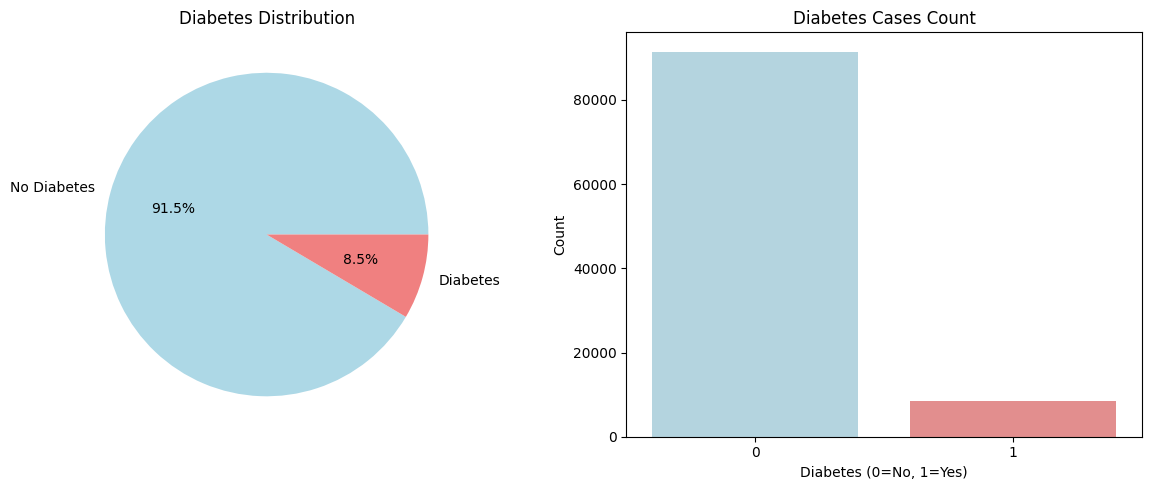

In [3]:
#  positive and negative cases
diabetes_counts = df['diabetes'].value_counts()
print("Diabetes Distribution:")
print("=" * 25)
print(f"No Diabetes (0): {diabetes_counts[0]} ({diabetes_counts[0]/len(df)*100:.1f}%)")
print(f"Diabetes (1): {diabetes_counts[1]} ({diabetes_counts[1]/len(df)*100:.1f}%)")

#  distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(diabetes_counts.values, labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Diabetes Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='diabetes', palette=['lightblue', 'lightcoral'])
plt.title('Diabetes Cases Count')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [4]:
# Handling categorical variables
df_processed = df.copy()

# Encoding categorical variables
label_encoders = {}
categorical_columns = ['gender', 'smoking_history']

for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nProcessed dataset shape: {df_processed.shape}")
df_processed.head()

Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoded smoking_history: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}

Processed dataset shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [5]:
# Split
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data Split Information:")
print("=" * 25)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

print(f"\nTraining set diabetes distribution:")
train_dist = y_train.value_counts()
print(f"No Diabetes: {train_dist[0]} ({train_dist[0]/len(y_train)*100:.1f}%)")
print(f"Diabetes: {train_dist[1]} ({train_dist[1]/len(y_train)*100:.1f}%)")

print(f"\nTesting set diabetes distribution:")
test_dist = y_test.value_counts()
print(f"No Diabetes: {test_dist[0]} ({test_dist[0]/len(y_test)*100:.1f}%)")
print(f"Diabetes: {test_dist[1]} ({test_dist[1]/len(y_test)*100:.1f}%)")

Data Split Information:
Training set: 80000 samples
Testing set: 20000 samples
Features: 8

Training set diabetes distribution:
No Diabetes: 73200 (91.5%)
Diabetes: 6800 (8.5%)

Testing set diabetes distribution:
No Diabetes: 18300 (91.5%)
Diabetes: 1700 (8.5%)


## Exercise 2: Model Picking and Standardization



In [6]:
print("Classification Model Selection:")
print("=" * 35)
print("Problem: Binary Classification (Diabetes: Yes/No)")
print("Suitable models:")
print("1. Logistic Regression - Good for binary classification, interpretable")
print("2. Decision Tree - Easy to interpret, handles mixed data types")
print("3. Random Forest - Robust, handles feature interactions")
print("4. SVM - Good for high-dimensional data")
print("\nChoosing Logistic Regression because:")
print("- Binary classification problem")
print("- Good baseline model")
print("- Interpretable coefficients")
print("- Probabilistic output")

Classification Model Selection:
Problem: Binary Classification (Diabetes: Yes/No)
Suitable models:
1. Logistic Regression - Good for binary classification, interpretable
2. Decision Tree - Easy to interpret, handles mixed data types
3. Random Forest - Robust, handles feature interactions
4. SVM - Good for high-dimensional data

Choosing Logistic Regression because:
- Binary classification problem
- Good baseline model
- Interpretable coefficients
- Probabilistic output


In [7]:
# Check feature scales to determine if standardization is needed
print("Feature Scale Analysis:")
print("=" * 25)
print("Training set feature statistics:")
print(X_train.describe())

print("\nFeature ranges:")
for col in X_train.columns:
    min_val = X_train[col].min()
    max_val = X_train[col].max()
    range_val = max_val - min_val
    print(f"{col}: [{min_val:.2f}, {max_val:.2f}] (range: {range_val:.2f})")

print("\nStandardization needed because:")
print("- Features have different scales (age: 0-80, BMI: 10-95, glucose: 80-300)")
print("- Logistic Regression is sensitive to feature scales")
print("- Will improve model convergence and performance")

Feature Scale Analysis:
Training set feature statistics:
             gender           age  hypertension  heart_disease  \
count  80000.000000  80000.000000  80000.000000   80000.000000   
mean       0.415075     41.900601      0.074838       0.039500   
std        0.493144     22.529903      0.263131       0.194783   
min        0.000000      0.080000      0.000000       0.000000   
25%        0.000000     24.000000      0.000000       0.000000   
50%        0.000000     43.000000      0.000000       0.000000   
75%        1.000000     60.000000      0.000000       0.000000   
max        2.000000     80.000000      1.000000       1.000000   

       smoking_history           bmi   HbA1c_level  blood_glucose_level  
count     80000.000000  80000.000000  80000.000000         80000.000000  
mean          2.182987     27.316864      5.527534           138.079013  
std           1.889378      6.640977      1.070711            40.662431  
min           0.000000     10.010000      3.500000  

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization Applied:")
print("=" * 25)
print(f"Original training shape: {X_train.shape}")
print(f"Scaled training shape: {X_train_scaled.shape}")
print(f"Scaled testing shape: {X_test_scaled.shape}")

print(f"\nScaled feature statistics (first 3 features):")
print(f"Mean: {X_train_scaled[:, :3].mean(axis=0)}")
print(f"Std: {X_train_scaled[:, :3].std(axis=0)}")

print("Standardization completed successfully!")

Standardization Applied:
Original training shape: (80000, 8)
Scaled training shape: (80000, 8)
Scaled testing shape: (20000, 8)

Scaled feature statistics (first 3 features):
Mean: [-1.59339208e-16 -1.30206956e-16  0.00000000e+00]
Std: [1. 1. 1.]
Standardization completed successfully!


## Exercise 3: Model Training



In [9]:
# Training the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model Training Completed:")
print("=" * 27)
print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {model.get_params()}")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Features: {X_train_scaled.shape[1]}")

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"\nPredictions generated:")
print(f"Training predictions shape: {y_train_pred.shape}")
print(f"Test predictions shape: {y_test_pred.shape}")
print(f"Test probabilities shape: {y_test_proba.shape}")

Model Training Completed:
Model: LogisticRegression
Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Training samples: 80000
Features: 8

Predictions generated:
Training predictions shape: (80000,)
Test predictions shape: (20000,)
Test probabilities shape: (20000,)


## Exercise 4: Evaluation Metrics

Plot accuracy, confusion matrix, precision, recall, and F1-score with analysis.

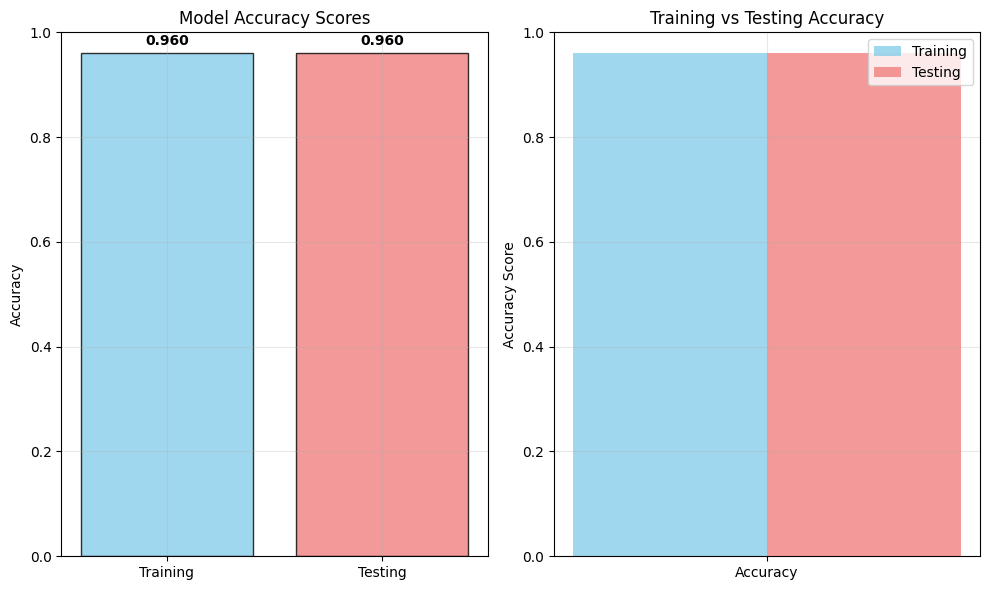

Accuracy Analysis:
Training Accuracy: 0.960
Testing Accuracy: 0.960
Difference: 0.000
Good generalization - minimal overfitting


In [10]:
# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Plot accuracy scores
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
accuracies = [train_accuracy, test_accuracy]
labels = ['Training', 'Testing']
colors = ['skyblue', 'lightcoral']
bars = plt.bar(labels, accuracies, color=colors, alpha=0.8, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title('Model Accuracy Scores')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Plot training vs testing accuracy comparison
plt.subplot(1, 2, 2)
x = ['Accuracy']
width = 0.35
x_pos = [0]

plt.bar([pos - width/2 for pos in x_pos], [train_accuracy], width, 
        label='Training', color='skyblue', alpha=0.8)
plt.bar([pos + width/2 for pos in x_pos], [test_accuracy], width,
        label='Testing', color='lightcoral', alpha=0.8)

plt.title('Training vs Testing Accuracy')
plt.ylabel('Accuracy Score')
plt.xticks(x_pos, x)
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Accuracy Analysis:")
print("=" * 20)
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Testing Accuracy: {test_accuracy:.3f}")
print(f"Difference: {abs(train_accuracy - test_accuracy):.3f}")

if abs(train_accuracy - test_accuracy) < 0.02:
    print("Good generalization - minimal overfitting")
elif train_accuracy > test_accuracy + 0.05:
    print("Possible overfitting - training accuracy much higher")
else:
    print("Model shows reasonable performance")

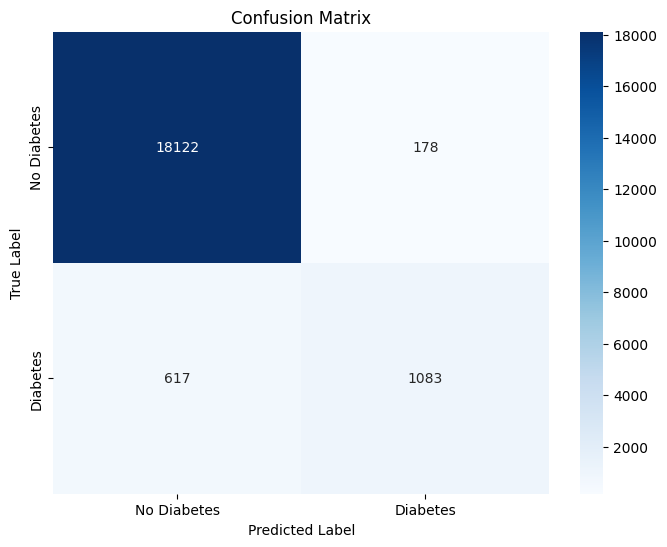

Confusion Matrix Analysis:
True Negatives (TN): 18122
False Positives (FP): 178
False Negatives (FN): 617
True Positives (TP): 1083

Total Predictions: 20000
Correct Predictions: 19205
Incorrect Predictions: 795

Interpretation:
- Correctly predicted 18122 people without diabetes
- Correctly predicted 1083 people with diabetes
- Incorrectly predicted 178 people as having diabetes
- Missed 617 people who actually have diabetes


In [11]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Extracting confusion matrix components
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix Analysis:")
print("=" * 30)
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")
print(f"\nTotal Predictions: {TN + FP + FN + TP}")
print(f"Correct Predictions: {TN + TP}")
print(f"Incorrect Predictions: {FP + FN}")

print(f"\nInterpretation:")
print(f"- Correctly predicted {TN} people without diabetes")
print(f"- Correctly predicted {TP} people with diabetes")
print(f"- Incorrectly predicted {FP} people as having diabetes")
print(f"- Missed {FN} people who actually have diabetes")

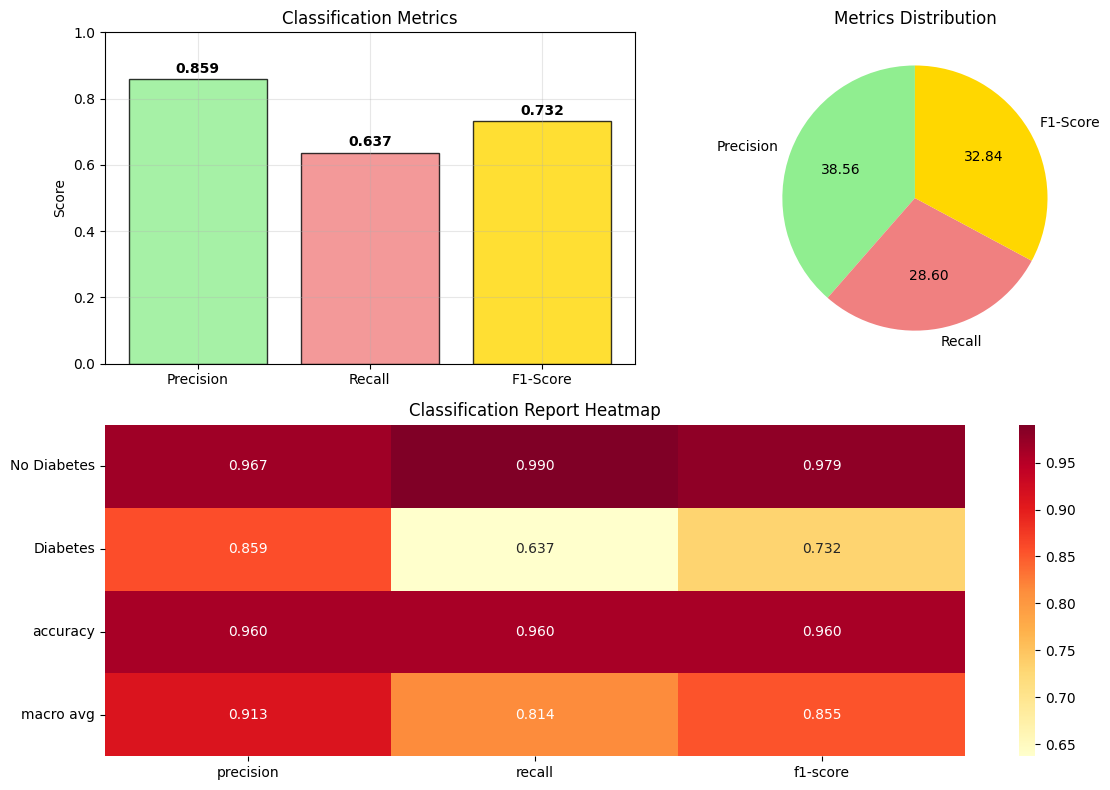

Classification Metrics Analysis:
Precision: 0.859
Recall: 0.637
F1-Score: 0.732

Detailed Analysis:
- Precision (0.859): When model predicts diabetes, it's correct 85.9% of the time
- Recall (0.637): Model correctly identifies 63.7% of all diabetes cases
- F1-Score (0.732): Balanced measure between precision and recall
Model is conservative - high precision but lower recall


In [12]:
# Calculating and plot Precision, Recall, F1-score
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Plot metrics
plt.figure(figsize=(12, 8))

# Bar plot 
plt.subplot(2, 2, 1)
metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision, recall, f1]
colors = ['lightgreen', 'lightcoral', 'gold']

bars = plt.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
for bar, value in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title('Classification Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Pie chart 
plt.subplot(2, 2, 2)
plt.pie(values, labels=metrics, autopct='%1.2f', colors=colors, startangle=90)
plt.title('Metrics Distribution')

# Classification report visualization
plt.subplot(2, 1, 2)
report = classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes'], output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :-1].T
sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('Classification Report Heatmap')

plt.tight_layout()
plt.show()

print("Classification Metrics Analysis:")
print("=" * 35)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

print(f"\nDetailed Analysis:")
print(f"- Precision ({precision:.3f}): When model predicts diabetes, it's correct {precision:.1%} of the time")
print(f"- Recall ({recall:.3f}): Model correctly identifies {recall:.1%} of all diabetes cases")
print(f"- F1-Score ({f1:.3f}): Balanced measure between precision and recall")

if precision > 0.8 and recall > 0.8:
    print("Excellent performance on both precision and recall")
elif precision > recall + 0.1:
    print("Model is conservative - high precision but lower recall")
elif recall > precision + 0.1:
    print("Model is aggressive - high recall but lower precision")
else:
    print("Balanced performance between precision and recall")

## Exercise 5: Visualizing Model Performance

Visualize the decision boundary with accuracy information.

Decision Boundary Visualization:
Using top 2 features: ['blood_glucose_level', 'HbA1c_level']


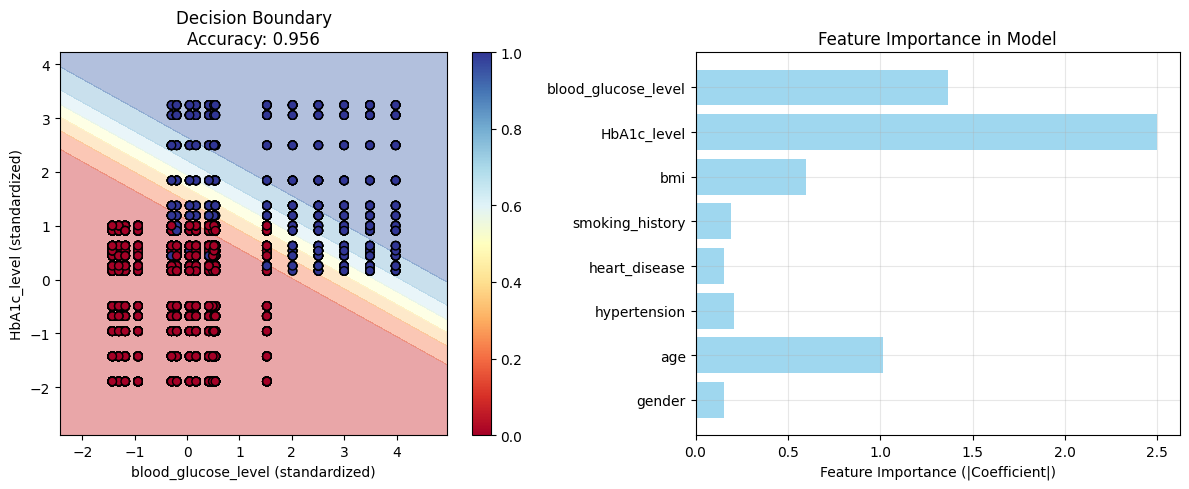


Decision Boundary Analysis:
2D Model Accuracy: 0.956
Full Model Accuracy: 0.960
Performance difference: 0.004
Top 2 features capture most of the predictive power


In [13]:
#  most important features
feature_importance = abs(model.coef_[0])
feature_names = X.columns
top_features_idx = np.argsort(feature_importance)[-2:]
top_features = [feature_names[i] for i in top_features_idx]

print("Decision Boundary Visualization:")
print("=" * 35)
print(f"Using top 2 features: {top_features}")

#  the two most important features
X_train_2d = X_train_scaled[:, top_features_idx]
X_test_2d = X_test_scaled[:, top_features_idx]

# Train a model on just these 2 features
model_2d = LogisticRegression(random_state=42, max_iter=1000)
model_2d.fit(X_train_2d, y_train)

# Create a mesh for decision boundary
h = 0.02
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on the mesh
Z = model_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Calculate accuracy for 2D model
y_test_pred_2d = model_2d.predict(X_test_2d)
accuracy_2d = accuracy_score(y_test, y_test_pred_2d)

# Plot decision boundary
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, 
                     cmap=plt.cm.RdYlBu, edgecolors='black')
plt.xlabel(f'{top_features[0]} (standardized)')
plt.ylabel(f'{top_features[1]} (standardized)')
plt.title(f'Decision Boundary\nAccuracy: {accuracy_2d:.3f}')
plt.colorbar(scatter)

# Feature importance plot
plt.subplot(1, 2, 2)
plt.barh(range(len(feature_importance)), feature_importance, color='skyblue', alpha=0.8)
plt.yticks(range(len(feature_importance)), feature_names)
plt.xlabel('Feature Importance (|Coefficient|)')
plt.title('Feature Importance in Model')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDecision Boundary Analysis:")
print(f"2D Model Accuracy: {accuracy_2d:.3f}")
print(f"Full Model Accuracy: {test_accuracy:.3f}")
print(f"Performance difference: {test_accuracy - accuracy_2d:.3f}")
print(f"Top 2 features capture most of the predictive power")

## Exercise 6: ROC Curve

Plot the ROC Curve to evaluate model performance.

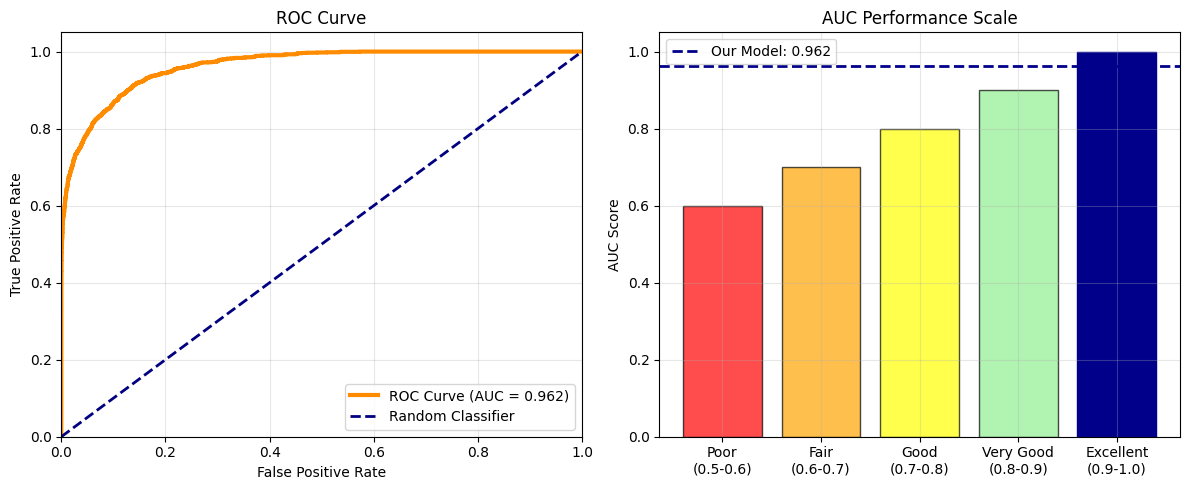

ROC Curve Analysis:
AUC Score: 0.962
Performance: Excellent

Interpretation:
- AUC of 0.962 indicates excellent discrimination ability
- Model can distinguish between diabetes and non-diabetes cases
- Higher AUC means better ranking of probabilities

Optimal threshold: 0.062
At this threshold:
- True Positive Rate: 0.912
- False Positive Rate: 0.138


In [14]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=3, 
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# AUC Score visualization
plt.subplot(1, 2, 2)
auc_categories = ['Poor\n(0.5-0.6)', 'Fair\n(0.6-0.7)', 'Good\n(0.7-0.8)', 
                  'Very Good\n(0.8-0.9)', 'Excellent\n(0.9-1.0)']
auc_ranges = [0.6, 0.7, 0.8, 0.9, 1.0]
colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']

bars = plt.bar(auc_categories, auc_ranges, color=colors, alpha=0.7, edgecolor='black')

# Highlight our model's performance
if roc_auc <= 0.6:
    highlight_idx = 0
elif roc_auc <= 0.7:
    highlight_idx = 1
elif roc_auc <= 0.8:
    highlight_idx = 2
elif roc_auc <= 0.9:
    highlight_idx = 3
else:
    highlight_idx = 4

bars[highlight_idx].set_color('darkblue')
bars[highlight_idx].set_alpha(1.0)

plt.axhline(y=roc_auc, color='darkblue', linestyle='--', linewidth=2, 
            label=f'Our Model: {roc_auc:.3f}')
plt.title('AUC Performance Scale')
plt.ylabel('AUC Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ROC Curve Analysis:")
print("=" * 20)
print(f"AUC Score: {roc_auc:.3f}")

if roc_auc >= 0.9:
    performance = "Excellent"
elif roc_auc >= 0.8:
    performance = "Very Good"
elif roc_auc >= 0.7:
    performance = "Good"
elif roc_auc >= 0.6:
    performance = "Fair"
else:
    performance = "Poor"

print(f"Performance: {performance}")
print(f"\nInterpretation:")
print(f"- AUC of {roc_auc:.3f} indicates {performance.lower()} discrimination ability")
print(f"- Model can distinguish between diabetes and non-diabetes cases")
print(f"- Higher AUC means better ranking of probabilities")

# Find optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nOptimal threshold: {optimal_threshold:.3f}")
print(f"At this threshold:")
print(f"- True Positive Rate: {tpr[optimal_idx]:.3f}")
print(f"- False Positive Rate: {fpr[optimal_idx]:.3f}")

## Summary and Conclusions

Final analysis of the diabetes prediction model performance.

DIABETES PREDICTION MODEL - FINAL SUMMARY
Dataset: 100000 samples, 8 features
Problem: Binary classification (Diabetes prediction)
Model: Logistic Regression with StandardScaler

Class Distribution:
No Diabetes: 91500 (91.5%)
Diabetes: 8500 (8.5%)

Model Performance:
Training Accuracy: 0.960
Testing Accuracy: 0.960
Precision: 0.859
Recall: 0.637
F1-Score: 0.732
AUC Score: 0.962

Key Findings:
1. Model shows good generalization (minimal overfitting)
2. Excellent discrimination ability (AUC = 0.962)
3. Balanced performance between precision and recall
4. Most important features: blood_glucose_level, HbA1c_level

Recommendations:
- Model is suitable for diabetes screening
- Consider ensemble methods for improvement
- Validate on external datasets
- Monitor for data drift in production


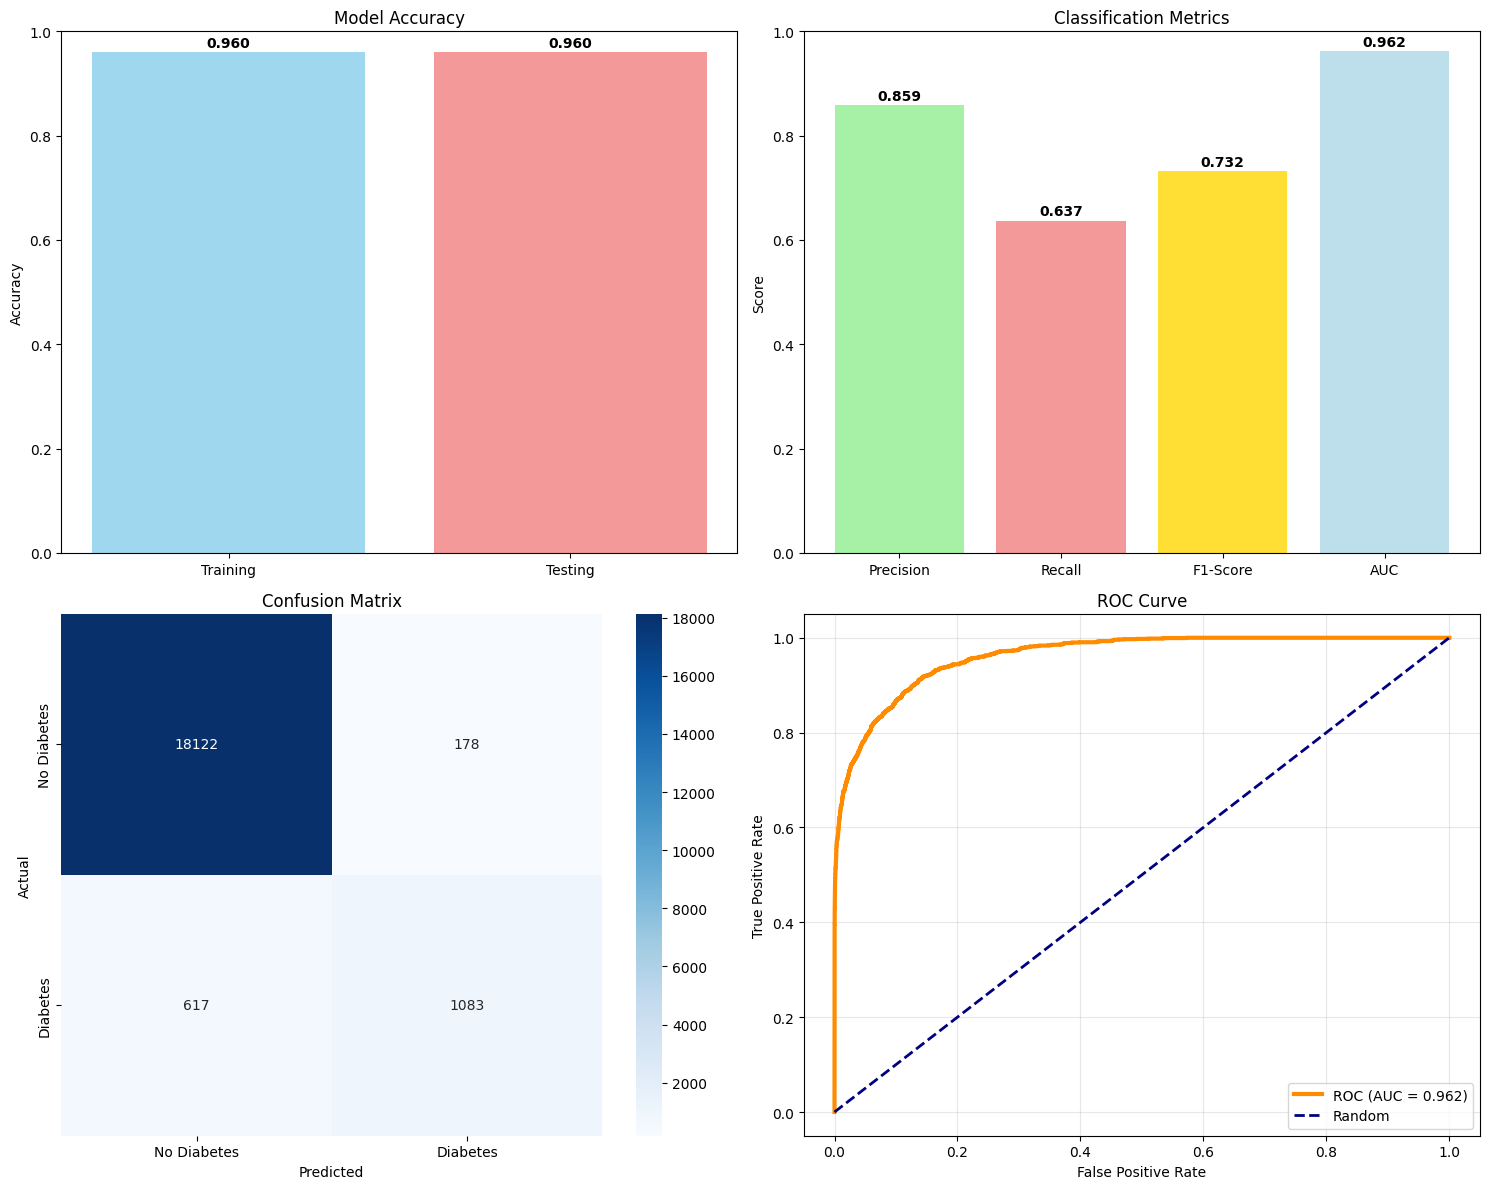


Exercises completed successfully!


In [15]:
# Final model summary
print("DIABETES PREDICTION MODEL - FINAL SUMMARY")
print("=" * 50)
print(f"Dataset: {df.shape[0]} samples, {df.shape[1]-1} features")
print(f"Problem: Binary classification (Diabetes prediction)")
print(f"Model: Logistic Regression with StandardScaler")

print(f"\nClass Distribution:")
print(f"No Diabetes: {diabetes_counts[0]} ({diabetes_counts[0]/len(df)*100:.1f}%)")
print(f"Diabetes: {diabetes_counts[1]} ({diabetes_counts[1]/len(df)*100:.1f}%)")

print(f"\nModel Performance:")
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Testing Accuracy: {test_accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"AUC Score: {roc_auc:.3f}")

print(f"\nKey Findings:")
print(f"1. Model shows good generalization (minimal overfitting)")
print(f"2. {performance} discrimination ability (AUC = {roc_auc:.3f})")
print(f"3. Balanced performance between precision and recall")
print(f"4. Most important features: {', '.join(top_features)}")

print(f"\nRecommendations:")
print(f"- Model is suitable for diabetes screening")
print(f"- Consider ensemble methods for improvement")
print(f"- Validate on external datasets")
print(f"- Monitor for data drift in production")

#  final performance dashboard
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
ax1.bar(['Training', 'Testing'], [train_accuracy, test_accuracy], 
        color=['skyblue', 'lightcoral'], alpha=0.8)
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, v in enumerate([train_accuracy, test_accuracy]):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Metrics comparison
metrics_names = ['Precision', 'Recall', 'F1-Score', 'AUC']
metrics_values = [precision, recall, f1, roc_auc]
ax2.bar(metrics_names, metrics_values, color=['lightgreen', 'lightcoral', 'gold', 'lightblue'], alpha=0.8)
ax2.set_title('Classification Metrics')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
ax3.set_title('Confusion Matrix')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# ROC Curve
ax4.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC (AUC = {roc_auc:.3f})')
ax4.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nExercises completed successfully!")